<a href="https://colab.research.google.com/github/Sunidhi-Gautam/FL_Implementation/blob/main/Plain_FL_FedAvg_Tomato.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ============================================================
# IMPORTS
# ============================================================

import os
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
# ============================================================
# CHECKPOINT DIRECTORY (Google Drive)
# ============================================================

CHECKPOINT_DIR = "/content/drive/MyDrive/plain_federated_tomato_training"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("Checkpoint directory:", CHECKPOINT_DIR)

Checkpoint directory: /content/drive/MyDrive/plain_federated_tomato_training


In [ ]:
import random

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

In [ ]:
# ============================================================
# INSTALL + DOWNLOAD DATASET
# ============================================================

# Install Kaggle
!pip install -q kaggle

from google.colab import files
files.upload()   # Upload kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [ ]:
!kaggle datasets download -d ashishmotwani/tomato
!kaggle datasets download -d kaustubhb999/tomatoleaf
!kaggle datasets download -d luisolazo/tomato-diseases

!unzip -q tomato.zip -d tomato_A
!unzip -q tomatoleaf.zip -d tomato_B
!unzip -q tomato-diseases.zip -d tomato_unseen

print("Datasets extracted.")

Dataset URL: https://www.kaggle.com/datasets/ashishmotwani/tomato
License(s): copyright-authors
100% 1.37G/1.37G [00:36<00:00, 40.8MB/s]

Dataset URL: https://www.kaggle.com/datasets/kaustubhb999/tomatoleaf
License(s): CC0-1.0
100% 179M/179M [00:05<00:00, 36.5MB/s]

Dataset URL: https://www.kaggle.com/datasets/luisolazo/tomato-diseases
License(s): CC0-1.0
100% 411M/411M [00:11<00:00, 38.8MB/s]

Datasets extracted.


Dataset Preprocessing

In [ ]:
# ============================================================
# Folder Structure Inspection
# ============================================================

def show_tree(path, depth=3):
    for root, dirs, files in os.walk(path):
        level = root.replace(path, '').count(os.sep)
        if level < depth:
            print("  " * level + os.path.basename(root))

print("=== Dataset A ===")
show_tree("tomato_A")

print("\n=== Dataset B ===")
show_tree("tomato_B", depth=4)

print("\n=== Unseen Dataset ===")
show_tree("tomato_unseen")

=== Dataset A ===
tomato_A
  valid
    healthy
    Tomato_Yellow_Leaf_Curl_Virus
    Early_blight
    Target_Spot
    Leaf_Mold
    Spider_mites Two-spotted_spider_mite
    Late_blight
    Septoria_leaf_spot
    Bacterial_spot
    powdery_mildew
    Tomato_mosaic_virus
  train
    healthy
    Tomato_Yellow_Leaf_Curl_Virus
    Early_blight
    Target_Spot
    Leaf_Mold
    Spider_mites Two-spotted_spider_mite
    Late_blight
    Septoria_leaf_spot
    Bacterial_spot
    powdery_mildew
    Tomato_mosaic_virus

=== Dataset B ===
tomato_B
  tomato
    val
      Tomato___Bacterial_spot
      Tomato___Tomato_Yellow_Leaf_Curl_Virus
      Tomato___Target_Spot
      Tomato___healthy
      Tomato___Tomato_mosaic_virus
      Tomato___Septoria_leaf_spot
      Tomato___Spider_mites Two-spotted_spider_mite
      Tomato___Leaf_Mold
      Tomato___Early_blight
      Tomato___Late_blight
    train
      Tomato___Bacterial_spot
      Tomato___Tomato_Yellow_Leaf_Curl_Virus
      Tomato___Target_Spot
    

In [ ]:
# ============================================================
# Delete the extra class
# ============================================================

import shutil

paths_to_delete = [
    "tomato_A/train/powdery_mildew",
    "tomato_A/valid/powdery_mildew"
]

for p in paths_to_delete:
    if os.path.exists(p):
        shutil.rmtree(p)
        print(f"Deleted: {p}")

Deleted: tomato_A/train/powdery_mildew
Deleted: tomato_A/valid/powdery_mildew


In [ ]:
# ============================================================
# Inspect folder structures again
# ============================================================

def show_tree(path, depth=3):
    for root, dirs, files in os.walk(path):
        level = root.replace(path, '').count(os.sep)
        if level < depth:
            print("  " * level + os.path.basename(root))

print("=== Dataset A ===")
show_tree("tomato_A")

print("\n=== Dataset B ===")
show_tree("tomato_B", depth=4)

print("\n=== Unseen Dataset ===")
show_tree("tomato_unseen")

=== Dataset A ===
tomato_A
  valid
    healthy
    Tomato_Yellow_Leaf_Curl_Virus
    Early_blight
    Target_Spot
    Leaf_Mold
    Spider_mites Two-spotted_spider_mite
    Late_blight
    Septoria_leaf_spot
    Bacterial_spot
    Tomato_mosaic_virus
  train
    healthy
    Tomato_Yellow_Leaf_Curl_Virus
    Early_blight
    Target_Spot
    Leaf_Mold
    Spider_mites Two-spotted_spider_mite
    Late_blight
    Septoria_leaf_spot
    Bacterial_spot
    Tomato_mosaic_virus

=== Dataset B ===
tomato_B
  tomato
    val
      Tomato___Bacterial_spot
      Tomato___Tomato_Yellow_Leaf_Curl_Virus
      Tomato___Target_Spot
      Tomato___healthy
      Tomato___Tomato_mosaic_virus
      Tomato___Septoria_leaf_spot
      Tomato___Spider_mites Two-spotted_spider_mite
      Tomato___Leaf_Mold
      Tomato___Early_blight
      Tomato___Late_blight
    train
      Tomato___Bacterial_spot
      Tomato___Tomato_Yellow_Leaf_Curl_Virus
      Tomato___Target_Spot
      Tomato___healthy
      Tomato___Toma

In [ ]:
# ============================================================
# Dataset Scanning for any missing / corrupt values
# ============================================================

from PIL import Image
import pandas as pd
from tqdm import tqdm

def scan_dataset(root_dir, dataset_name):
    records = []
    broken = []

    for root, dirs, files in os.walk(root_dir):
      dirs.sort()
      files.sort()
      for file in files:
          if file.lower().endswith((".jpg", ".jpeg", ".png")):
              path = os.path.join(root, file)
              label = os.path.basename(root)
              try:
                  img = Image.open(path)
                  img.verify()
                  records.append({
                      "dataset": dataset_name,
                      "path": path,
                      "raw_label": label
                  })
              except:
                  broken.append(path)

    print(f"{dataset_name}: {len(records)} valid images")
    print(f"{dataset_name}: {len(broken)} broken images")

    return pd.DataFrame(records)

df_A = scan_dataset("tomato_A", "A")
df_B = scan_dataset("tomato_B/tomato", "B")
df_C = scan_dataset("tomato_unseen", "C")

df_raw = pd.concat([df_A, df_B, df_C]).reset_index(drop=True)

print("Total images:", len(df_raw))

A: 31278 valid images
A: 0 broken images
B: 11000 valid images
B: 0 broken images
C: 22193 valid images
C: 0 broken images
Total images: 64471


Label Harmonization

In [ ]:
# ============================================================
# Canonical Labels
# ============================================================

canonical_labels = [
    "bacterial_spot",
    "early_blight",
    "late_blight",
    "leaf_mold",
    "mosaic_virus",
    "septoria_leaf_spot",
    "spider_mites",
    "target_spot",
    "yellow_leaf_curl_virus",
    "healthy"
]

label_to_id = {label: idx for idx, label in enumerate(canonical_labels)}
id_to_label = {idx: label for idx, label in enumerate(canonical_labels)}

In [ ]:
# ============================================================
# Dataset-Specific Label Mapping
# ============================================================

mapping_A = {
    "Bacterial_spot": "bacterial_spot",
    "Early_blight": "early_blight",
    "Late_blight": "late_blight",
    "Leaf_Mold": "leaf_mold",
    "Tomato_mosaic_virus": "mosaic_virus",
    "Septoria_leaf_spot": "septoria_leaf_spot",
    "Spider_mites Two-spotted_spider_mite": "spider_mites",
    "Target_Spot": "target_spot",
    "Tomato_Yellow_Leaf_Curl_Virus": "yellow_leaf_curl_virus",
    "healthy": "healthy"
}

mapping_B = {
    "Tomato___Bacterial_spot": "bacterial_spot",
    "Tomato___Early_blight": "early_blight",
    "Tomato___Late_blight": "late_blight",
    "Tomato___Leaf_Mold": "leaf_mold",
    "Tomato___Tomato_mosaic_virus": "mosaic_virus",
    "Tomato___Septoria_leaf_spot": "septoria_leaf_spot",
    "Tomato___Spider_mites Two-spotted_spider_mite": "spider_mites",
    "Tomato___Target_Spot": "target_spot",
    "Tomato___Tomato_Yellow_Leaf_Curl_Virus": "yellow_leaf_curl_virus",
    "Tomato___healthy": "healthy"
}

mapping_C = {
    "bacterial_spot": "bacterial_spot",
    "early_blight": "early_blight",
    "late_blight": "late_blight",
    "leaf_mold": "leaf_mold",
    "mosaic_virus": "mosaic_virus",
    "septoria_leaf_spot": "septoria_leaf_spot",
    "twospotted_spider_mite": "spider_mites",
    "target_spot": "target_spot",
    "yellow_leaf_curl_virus": "yellow_leaf_curl_virus",
    "healthy": "healthy"
}

In [ ]:
# ============================================================
# Apply Harmonization
# ============================================================

def harmonize(row):
    if row['dataset'] == 'A':
        return mapping_A[row['raw_label']]
    elif row['dataset'] == 'B':
        return mapping_B[row['raw_label']]
    elif row['dataset'] == 'C':
        return mapping_C[row['raw_label']]

df_raw['canonical_label'] = df_raw.apply(harmonize, axis=1)
df_raw['class_id'] = df_raw['canonical_label'].map(label_to_id)

Client Mapping

In [ ]:
client_mapping = {
    'A': 0,
    'B': 1,
    'C': 2
}

df_raw['domain'] = df_raw['dataset'].map(client_mapping)

In [ ]:
# ============================================================
# FINAL DATAFRAME FOR TRAINING
# ============================================================

df_all = df_raw.copy()

labels = canonical_labels
NUM_CLASSES = len(labels)

print("Total images:", len(df_all))
print("Number of classes:", NUM_CLASSES)

Total images: 64471
Number of classes: 10


Domain Distribution per Dataset

In [ ]:
print("Domain distribution per dataset:")
print(df_raw.groupby(['dataset', 'domain']).size())

print("\nSample dataframe with domain labels:")
df_raw.head()

Domain distribution per dataset:
dataset  domain
A        0         31278
B        1         11000
C        2         22193
dtype: int64

Sample dataframe with domain labels:


,dataset,path,raw_label,canonical_label,class_id,domain
0,A,tomato_A/train/Bacterial_spot/00416648-be6e-4b...,Bacterial_spot,bacterial_spot,0,0
1,A,tomato_A/train/Bacterial_spot/0045ba29-ed1b-43...,Bacterial_spot,bacterial_spot,0,0
2,A,tomato_A/train/Bacterial_spot/00639d29-2d1a-4f...,Bacterial_spot,bacterial_spot,0,0
3,A,tomato_A/train/Bacterial_spot/00728f4d-83a0-49...,Bacterial_spot,bacterial_spot,0,0
4,A,tomato_A/train/Bacterial_spot/00a7c269-3476-4d...,Bacterial_spot,bacterial_spot,0,0


In [ ]:
# ============================================================
# SPLIT TRAINING DATASET
# ============================================================

def split_domain_three_way(df, domain_id):

    df_domain = df[df["domain"] == domain_id]

    # First split: Train (70%) and Temp (30%)
    train_df, temp_df = train_test_split(
        df_domain,
        train_size=0.7,
        stratify=df_domain["class_id"],
        random_state=42
    )

    # Second split: Val (15%) and Test (15%)
    val_df, test_df = train_test_split(
        temp_df,
        train_size=0.5,
        stratify=temp_df["class_id"],
        random_state=42
    )

    return train_df, val_df, test_df


train_A, val_A, test_A = split_domain_three_way(df_all, 0)
train_B, val_B, test_B = split_domain_three_way(df_all, 1)

# Domain C remains unseen test only
test_C = df_all[df_all["domain"] == 2]

In [ ]:
print("Domain A")
print("Train:", len(train_A))
print("Val:", len(val_A))
print("Test:", len(test_A))

print("\nDomain B")
print("Train:", len(train_B))
print("Val:", len(val_B))
print("Test:", len(test_B))

print("\nDomain C (Unseen Test Only):", len(test_C))

Domain A
Train: 21894
Val: 4692
Test: 4692

Domain B
Train: 7699
Val: 1650
Test: 1651

Domain C (Unseen Test Only): 22193


In [ ]:
# ============================================================
# DATA TRANSFORM
# ============================================================

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),

    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),

    transforms.RandomRotation(20),

    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3,
        hue=0.05
    ),

    transforms.RandomGrayscale(p=0.1),

    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
# ============================================================
# CREATING CUSTOM DATASET CLASS
# ============================================================

class TomatoDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        img_path = self.df.loc[idx, "path"]
        label = self.df.loc[idx, "class_id"]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
# ============================================================
# CALCULATING CLASS WEIGHTS
# ============================================================

def get_class_weights(df, num_classes):

    class_counts = df["class_id"].value_counts().sort_index()
    full_counts = np.zeros(num_classes)

    for i in class_counts.index:
        full_counts[i] = class_counts[i]

    full_counts = np.where(full_counts == 0, 1, full_counts)
    weights = 1.0 / full_counts

    return torch.tensor(weights, dtype=torch.float32).to(device)

class_weights_A = get_class_weights(train_A, NUM_CLASSES)
class_weights_B = get_class_weights(train_B, NUM_CLASSES)

In [ ]:
# ============================================================
# DATA LOADERS
# ============================================================

BATCH_SIZE = 16

# Train Loader
train_loader_A = DataLoader(TomatoDataset(train_A, train_transform), batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
train_loader_B = DataLoader(TomatoDataset(train_B, train_transform), batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)

# Val Loader
val_loader_A = DataLoader(TomatoDataset(val_A, test_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
val_loader_B = DataLoader(TomatoDataset(val_B, test_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Test Loader
test_loader_A = DataLoader(TomatoDataset(test_A, test_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader_B = DataLoader(TomatoDataset(test_B, test_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader_C = DataLoader(TomatoDataset(test_C, test_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

In [ ]:
# ============================================================
# DEFINING THE MODEL
# ============================================================

import torch.nn as nn
from torchvision import models

def get_model(num_classes, freeze_backbone=True):

    weights = ResNet18_Weights.DEFAULT
    model = resnet18(weights=weights)

    # Freeze backbone
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Replace final layer
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    return model

In [ ]:
n_A = len(train_A)
n_B = len(train_B)

total_samples = n_A + n_B

print("Client A samples:", n_A)
print("Client B samples:", n_B)

Client A samples: 21894
Client B samples: 7699


In [ ]:
# ============================================================
# LOCAL TRAINING FUNCTION
# ============================================================

def train_local(model, loader, class_weights, epochs=2, lr=3e-5):

    model.to(device)
    model.train()

    criterion = nn.CrossEntropyLoss(
        weight=class_weights,
        label_smoothing=0.1
    )

    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr
    )

    for _ in range(epochs):
        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    return model.state_dict()

In [ ]:
# ============================================================
# EVALUATION FUNCTION
# ============================================================

def evaluate(model, loader):

    model.to(device)
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    return 100 * correct / total

In [ ]:
# ============================================================
# WEIGHTED FEDAVG FUNCTION
# ============================================================

def weighted_fedavg(global_model, client_weights, client_sizes):

    new_state = copy.deepcopy(global_model.state_dict())

    total_samples = sum(client_sizes)

    for key in new_state.keys():

        weighted_sum = 0

        for i in range(len(client_weights)):
            weight = client_sizes[i] / total_samples
            weighted_sum += client_weights[i][key].float() * weight

        new_state[key] = weighted_sum

    global_model.load_state_dict(new_state)

    return global_model

In [ ]:
def load_latest_checkpoint():

    files = [f for f in os.listdir(CHECKPOINT_DIR) if "latest_round" in f]

    if len(files) == 0:
        return None, 1

    files.sort()
    latest = files[-1]

    path = os.path.join(CHECKPOINT_DIR, latest)

    checkpoint = torch.load(path, map_location=device)

    global_model.load_state_dict(
        checkpoint["global_model_state_dict"]
    )

    start_round = checkpoint["round"] + 1

    print("Loaded checkpoint:", latest)

    return checkpoint, start_round

In [ ]:
# ============================================================
# FEDERATED TRAINING LOOP (Improved Logging Version)
# ============================================================
from tqdm import tqdm

ROUNDS = 5
LOCAL_EPOCHS = 2
PATIENCE = 3

# ============================================================
# INITIALIZE GLOBAL MODEL
# ============================================================

global_model = get_model(NUM_CLASSES, freeze_backbone=True).to(device)

# ============================================================
# LOAD CHECKPOINT
# ============================================================

checkpoint, start_round = load_latest_checkpoint()

if checkpoint is None:
    start_round = 1
    print("Starting training from scratch")

    best_weights = copy.deepcopy(global_model.state_dict())
    best_val = 0
    no_improve = 0

    history_A = []
    history_B = []
    history_C = []

else:
    print(f"Resuming from round {start_round}")

    best_weights = copy.deepcopy(global_model.state_dict())
    best_val = checkpoint["best_val"]
    no_improve = 0

    history_A = checkpoint["history_A"]
    history_B = checkpoint["history_B"]
    history_C = checkpoint["history_C"]

n_A = len(train_A)
n_B = len(train_B)

for r in range(start_round-1, ROUNDS):

    print(f"\n================ ROUND {r+1}/{ROUNDS} ================")

    # --------------------------------------------------
    # CLIENT MODELS
    # --------------------------------------------------
    client_model_A = copy.deepcopy(global_model)
    client_model_B = copy.deepcopy(global_model)

    client_model_A.to(device)
    client_model_B.to(device)

    optimizer_A = optim.Adam(
        filter(lambda p: p.requires_grad, client_model_A.parameters()),
        lr = 3e-5
    )

    optimizer_B = optim.Adam(
        filter(lambda p: p.requires_grad, client_model_B.parameters()),
        lr = 3e-5
    )

    criterion_A = nn.CrossEntropyLoss(
        weight=class_weights_A,
        label_smoothing=0.1
    )

    criterion_B = nn.CrossEntropyLoss(
        weight=class_weights_B,
        label_smoothing=0.1
    )

    # --------------------------------------------------
    # LOCAL TRAINING
    # --------------------------------------------------
    for epoch in range(LOCAL_EPOCHS):

        client_model_A.train()
        client_model_B.train()

        epoch_loss_A = 0
        epoch_loss_B = 0

        iterator_A = iter(train_loader_A)
        iterator_B = iter(train_loader_B)

        num_steps = max(len(train_loader_A), len(train_loader_B))

        for step in tqdm(
            range(num_steps),
            desc=f"Round {r+1} | Epoch {epoch+1}",
            leave=False
        ):

            try:
                images_A, labels_A = next(iterator_A)
            except StopIteration:
                iterator_A = iter(train_loader_A)
                images_A, labels_A = next(iterator_A)

            try:
                images_B, labels_B = next(iterator_B)
            except StopIteration:
                iterator_B = iter(train_loader_B)
                images_B, labels_B = next(iterator_B)

            images_A = images_A.to(device)
            labels_A = labels_A.to(device)

            images_B = images_B.to(device)
            labels_B = labels_B.to(device)

            # ---------------- CLIENT A ----------------
            optimizer_A.zero_grad()

            outputs_A = client_model_A(images_A)
            loss_A = criterion_A(outputs_A, labels_A)

            loss_A.backward()

            torch.nn.utils.clip_grad_norm_(
                client_model_A.parameters(), 5.0
            )

            optimizer_A.step()

            epoch_loss_A += loss_A.item()

            # ---------------- CLIENT B ----------------
            optimizer_B.zero_grad()

            outputs_B = client_model_B(images_B)
            loss_B = criterion_B(outputs_B, labels_B)

            loss_B.backward()

            torch.nn.utils.clip_grad_norm_(
                client_model_B.parameters(), 5.0
            )

            optimizer_B.step()

            epoch_loss_B += loss_B.item()

        # --------------------------------------------------
        # VALIDATION AFTER EACH LOCAL EPOCH
        # --------------------------------------------------
        val_acc_A = evaluate(client_model_A, val_loader_A)
        val_acc_B = evaluate(client_model_B, val_loader_B)

        tqdm.write(
            f"[Round {r+1} | Epoch {epoch+1}] "
            f"Loss A: {epoch_loss_A/num_steps:.4f} | "
            f"Loss B: {epoch_loss_B/num_steps:.4f} | "
            f"Val A: {val_acc_A:.2f}% | "
            f"Val B: {val_acc_B:.2f}%"
        )

    # --------------------------------------------------
    # SERVER AGGREGATION (FedAvg)
    # --------------------------------------------------
    print("\n--- Server Aggregation (FedAvg) ---")

    state_A = client_model_A.state_dict()
    state_B = client_model_B.state_dict()

    global_model = weighted_fedavg(
        global_model,
        [state_A, state_B],
        [n_A, n_B]
    )

    # --------------------------------------------------
    # GLOBAL VALIDATION
    # --------------------------------------------------
    val_acc_A = evaluate(global_model, val_loader_A)
    val_acc_B = evaluate(global_model, val_loader_B)

    val_avg = (val_acc_A + val_acc_B) / 2

    print(
        f"\nValidation Results:\n"
        f"Client A Val: {val_acc_A:.2f}% | "
        f"Client B Val: {val_acc_B:.2f}%"
    )

    # --------------------------------------------------
    # EARLY STOPPING
    # --------------------------------------------------
    if val_avg > best_val:
        best_val = val_avg
        no_improve = 0
        best_weights = copy.deepcopy(global_model.state_dict())

        best_path = os.path.join(
            CHECKPOINT_DIR,
            "best_model.pth"
        )

        torch.save({
            "round": r + 1,
            "best_val": best_val,
            "model_state_dict": global_model.state_dict()
        }, best_path)

        print(f"Best model saved at round {r+1}")

    else:
        no_improve += 1

    if no_improve >= PATIENCE:
        print("\nEarly stopping triggered.")
        break

    # --------------------------------------------------
    # TEST EVALUATION
    # --------------------------------------------------
    test_acc_A = evaluate(global_model, test_loader_A)
    test_acc_B = evaluate(global_model, test_loader_B)
    test_acc_C = evaluate(global_model, test_loader_C)

    history_A.append(test_acc_A)
    history_B.append(test_acc_B)
    history_C.append(test_acc_C)

    print(
        f"\nTest Results:\n"
        f"Client A Test: {test_acc_A:.2f}%\n"
        f"Client B Test: {test_acc_B:.2f}%\n"
        f"Unseen Domain C Test: {test_acc_C:.2f}%"
    )

    # ============================================================
    # SAVE CHECKPOINT
    # ============================================================

    checkpoint_path = os.path.join(
        CHECKPOINT_DIR,
        f"latest_round_{r+1}.pth"
    )

    torch.save({
        "round": r + 1,
        "best_val": best_val,
        "global_model_state_dict": global_model.state_dict(),
        "history_A": history_A,
        "history_B": history_B,
        "history_C": history_C
    }, checkpoint_path)

    print(f"Checkpoint saved: {checkpoint_path}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 87.5MB/s]


Starting training from scratch

================ ROUND 1/5 ================


[Round 1 | Epoch 1] Loss A: 2.1803 | Loss B: 2.1310 | Val A: 39.24% | Val B: 51.39%


[Round 1 | Epoch 2] Loss A: 1.9102 | Loss B: 1.8065 | Val A: 53.03% | Val B: 65.03%

--- Server Aggregation (FedAvg) ---

Validation Results:
Client A Val: 54.33% | Client B Val: 62.67%
Best model saved at round 1

Test Results:
Client A Test: 53.82%
Client B Test: 61.11%
Unseen Domain C Test: 56.81%
Checkpoint saved: /content/drive/MyDrive/plain_federated_tomato_training/latest_round_1.pth

================ ROUND 2/5 ================


...

[Round 3 | Epoch 2] Loss A: 1.5166 | Loss B: 1.3813 | Val A: 67.48% | Val B: 75.45%

--- Server Aggregation (FedAvg) ---

Validation Results:
Client A Val: 66.88% | Client B Val: 73.58%
Best model saved at round 3

Test Results:
Client A Test: 66.65%
Client B Test: 73.41%
Unseen Domain C Test: 68.09%
Checkpoint saved: /content/drive/MyDrive/plain_federated_tomato_training/latest_round_3.pth

================ ROUND 4/5 ================


[Round 4 | Epoch 1] Loss A: 1.4823 | Loss B: 1.3568 | Val A: 66.45% | Val B: 76.12%


[Round 4 | Epoch 2] Loss A: 1.4516 | Loss B: 1.3081 | Val A: 69.22% | Val B: 77.33%

--- Server Aggregation (FedAvg) ---

Validation Results:
Client A Val: 69.08% | Client B Val: 75.21%
Best model saved at round 4

Test Results:
Client A Test: 68.80%
Client B Test: 75.83%
Unseen Domain C Test: 69.99%
Checkpoint saved: /content/drive/MyDrive/plain_federated_tomato_training/latest_round_4.pth

================ ROUND 5/5 ================


[Round 5 | Epoch 1] Loss A: 1.4288 | Loss B: 1.3012 | Val A: 68.35% | Val B: 76.24%


[Round 5 | Epoch 2] Loss A: 1.4081 | Loss B: 1.2650 | Val A: 68.69% | Val B: 78.36%

--- Server Aggregation (FedAvg) ---

Validation Results:
Client A Val: 68.82% | Client B Val: 74.55%

Test Results:
Client A Test: 68.95%
Client B Test: 75.65%
Unseen Domain C Test: 69.90%
Checkpoint saved: /content/drive/MyDrive/plain_federated_tomato_training/latest_round_5.pth


In [ ]:
# ============================================================
# LOAD BEST MODEL
# ============================================================

global_model.load_state_dict(best_weights)
global_model = global_model.to(device)

In [ ]:
# ============================================================
# FINAL TEST RESULTS
# ============================================================

print("\n===== FINAL RESULTS (Best Model) =====")

final_A = evaluate(global_model, test_loader_A)
final_B = evaluate(global_model, test_loader_B)
final_C = evaluate(global_model, test_loader_C)

print(f"Final Test A: {final_A:.2f}%")
print(f"Final Test B: {final_B:.2f}%")
print(f"Final Test C (Unseen): {final_C:.2f}%")


===== FINAL RESULTS (Best Model) =====
Final Test A: 68.80%
Final Test B: 75.83%
Final Test C (Unseen): 69.99%


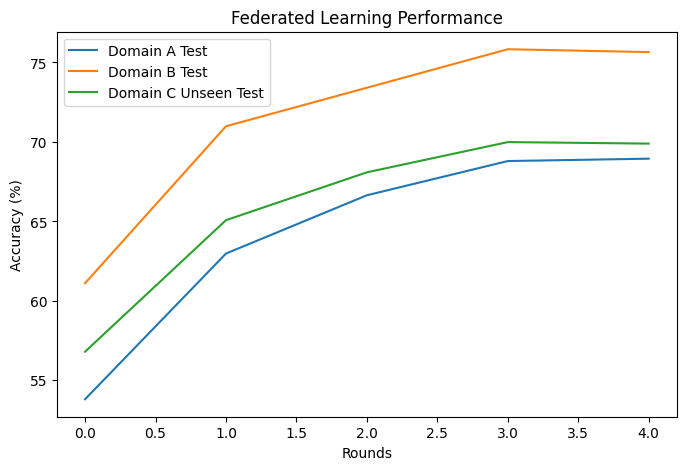

In [ ]:
# ============================================================
# PLOTTING ACCURACY CURVES
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(history_A, label="Domain A Test")
plt.plot(history_B, label="Domain B Test")
plt.plot(history_C, label="Domain C Unseen Test")

plt.xlabel("Rounds")
plt.ylabel("Accuracy (%)")
plt.title("Federated Learning Performance")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, balanced_accuracy_score
import seaborn as sns

def get_predictions(model, loader):

    model.to(device)
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)

In [ ]:
# ============================================================
# CONFUSION MATRIX FUNCTION
# ============================================================

def plot_confusion_matrix(model, loader, title):

    y_true, y_pred = get_predictions(model, loader)

    cm = confusion_matrix(y_true, y_pred)

    # Balanced Accuracy
    bal_acc = balanced_accuracy_score(y_true, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=labels,
                yticklabels=labels,
                cmap="Blues")

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.show()

    print("\nBalanced Accuracy:", round(bal_acc * 100, 2), "%")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=labels))

    return cm, bal_acc

In [ ]:
def class_wise_accuracy(cm):

    class_acc = {}

    for i, label in enumerate(labels):
        total = cm[i].sum()
        if total == 0:
            class_acc[label] = 0
        else:
            class_acc[label] = cm[i, i] / total

    return class_acc


CONFUSION MATRIX - DOMAIN A


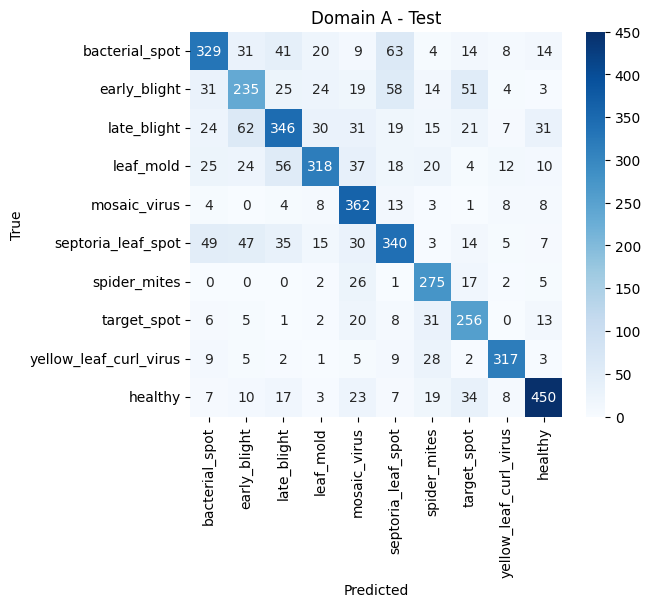


Balanced Accuracy: 70.23 %

Classification Report:
                        precision    recall  f1-score   support

        bacterial_spot       0.68      0.62      0.65       533
          early_blight       0.56      0.51      0.53       464
           late_blight       0.66      0.59      0.62       586
             leaf_mold       0.75      0.61      0.67       524
          mosaic_virus       0.64      0.88      0.74       411
    septoria_leaf_spot       0.63      0.62      0.63       545
          spider_mites       0.67      0.84      0.74       328
           target_spot       0.62      0.75      0.68       342
yellow_leaf_curl_virus       0.85      0.83      0.84       381
               healthy       0.83      0.78      0.80       578

              accuracy                           0.69      4692
             macro avg       0.69      0.70      0.69      4692
          weighted avg       0.69      0.69      0.69      4692


Class-wise Accuracy (Domain A):
bacterial_spot: 

In [ ]:
print("\n==============================")
print("CONFUSION MATRIX - DOMAIN A")
print("==============================")

cm_A, bal_A = plot_confusion_matrix(global_model, test_loader_A,
                                    title="Domain A - Test")

acc_A = class_wise_accuracy(cm_A)

print("\nClass-wise Accuracy (Domain A):")
for k, v in acc_A.items():
    print(f"{k}: {v:.4f}")


CONFUSION MATRIX - DOMAIN B


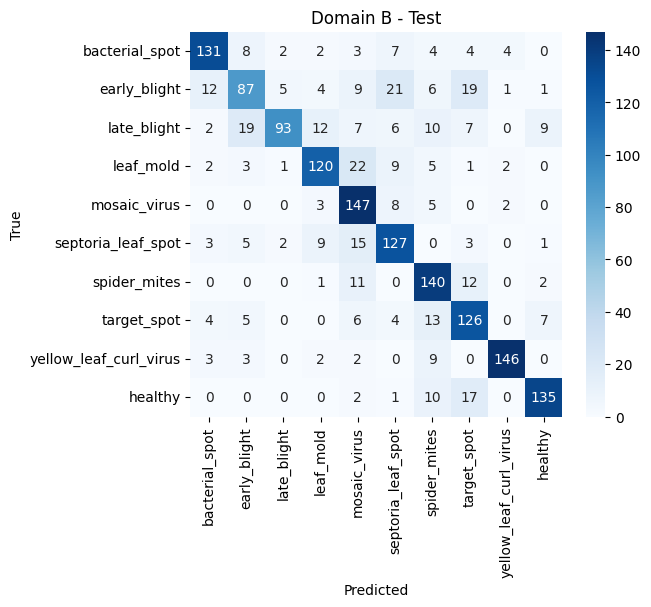


Balanced Accuracy: 75.83 %

Classification Report:
                        precision    recall  f1-score   support

        bacterial_spot       0.83      0.79      0.81       165
          early_blight       0.67      0.53      0.59       165
           late_blight       0.90      0.56      0.69       165
             leaf_mold       0.78      0.73      0.75       165
          mosaic_virus       0.66      0.89      0.76       165
    septoria_leaf_spot       0.69      0.77      0.73       165
          spider_mites       0.69      0.84      0.76       166
           target_spot       0.67      0.76      0.71       165
yellow_leaf_curl_virus       0.94      0.88      0.91       165
               healthy       0.87      0.82      0.84       165

              accuracy                           0.76      1651
             macro avg       0.77      0.76      0.76      1651
          weighted avg       0.77      0.76      0.76      1651


Class-wise Accuracy (Domain B):
bacterial_spot: 

In [ ]:
print("\n==============================")
print("CONFUSION MATRIX - DOMAIN B")
print("==============================")

cm_B, bal_B = plot_confusion_matrix(global_model, test_loader_B,
                                    title="Domain B - Test")

acc_B = class_wise_accuracy(cm_B)

print("\nClass-wise Accuracy (Domain B):")
for k, v in acc_B.items():
    print(f"{k}: {v:.4f}")


CONFUSION MATRIX - DOMAIN C (UNSEEN)


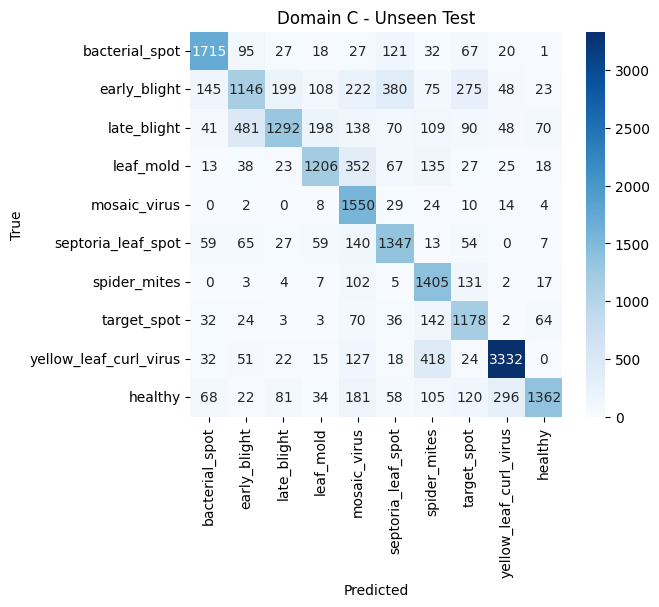


Balanced Accuracy: 70.99 %

Classification Report:
                        precision    recall  f1-score   support

        bacterial_spot       0.81      0.81      0.81      2123
          early_blight       0.59      0.44      0.50      2621
           late_blight       0.77      0.51      0.61      2537
             leaf_mold       0.73      0.63      0.68      1904
          mosaic_virus       0.53      0.94      0.68      1641
    septoria_leaf_spot       0.63      0.76      0.69      1771
          spider_mites       0.57      0.84      0.68      1676
           target_spot       0.60      0.76      0.67      1554
yellow_leaf_curl_virus       0.88      0.82      0.85      4039
               healthy       0.87      0.59      0.70      2327

              accuracy                           0.70     22193
             macro avg       0.70      0.71      0.69     22193
          weighted avg       0.72      0.70      0.70     22193


Class-wise Accuracy (Domain C):
bacterial_spot: 

In [ ]:
print("\n==============================")
print("CONFUSION MATRIX - DOMAIN C (UNSEEN)")
print("==============================")

cm_C, bal_C = plot_confusion_matrix(global_model, test_loader_C,
                                    title="Domain C - Unseen Test")

acc_C = class_wise_accuracy(cm_C)

print("\nClass-wise Accuracy (Domain C):")
for k, v in acc_C.items():
    print(f"{k}: {v:.4f}")

In [ ]:
print("\n==============================")
print("BALANCED ACCURACY SUMMARY")
print("==============================")

print(f"Domain A Balanced Accuracy: {bal_A*100:.2f}%")
print(f"Domain B Balanced Accuracy: {bal_B*100:.2f}%")
print(f"Domain C Balanced Accuracy: {bal_C*100:.2f}%")


BALANCED ACCURACY SUMMARY
Domain A Balanced Accuracy: 70.23%
Domain B Balanced Accuracy: 75.83%
Domain C Balanced Accuracy: 70.99%
